# Traffic Accident Data Analysis and Hotspot Visualization

In [1]:
!pip install pandas numpy matplotlib seaborn plotly folium openpyxl xlrd


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import folium
from folium.plugins import HeatMap

import warnings
warnings.filterwarnings("ignore")

In [2]:
!pip install xlrd


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_excel("US_Accidents_March23.xls", engine="xlrd")

In [4]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [5]:
df.shape

(65535, 46)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID                     65535 non-null  str           
 1   Source                 65535 non-null  str           
 2   Severity               65535 non-null  int64         
 3   Start_Time             65535 non-null  datetime64[us]
 4   End_Time               65535 non-null  datetime64[us]
 5   Start_Lat              65535 non-null  float64       
 6   Start_Lng              65535 non-null  float64       
 7   End_Lat                0 non-null      float64       
 8   End_Lng                0 non-null      float64       
 9   Distance(mi)           65535 non-null  float64       
 10  Description            65535 non-null  str           
 11  Street                 65535 non-null  str           
 12  City                   65535 non-null  str           
 13  County      

In [7]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

In [8]:
important_cols = [
    "Start_Time", "End_Time", "Severity",
    "Start_Lat", "Start_Lng",
    "City", "State",
    "Weather_Condition",
    "Temperature(F)", "Humidity(%)",
    "Visibility(mi)", "Wind_Speed(mph)",
    "Precipitation(in)",
    "Amenity", "Bump", "Crossing", "Give_Way",
    "Junction", "No_Exit", "Railway", "Roundabout",
    "Station", "Stop", "Traffic_Calming",
    "Traffic_Signal",
    "Sunrise_Sunset"
]

df[important_cols].head()

,Start_Time,End_Time,Severity,Start_Lat,Start_Lng,City,State,Weather_Condition,Temperature(F),Humidity(%),...,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Sunrise_Sunset
0,2016-02-08 05:46:00,2016-02-08 11:00:00,3,39.865147,-84.058723,Dayton,OH,Light Rain,36.9,91.0,...,False,False,False,False,False,False,False,False,False,Night
1,2016-02-08 06:07:59,2016-02-08 06:37:59,2,39.928059,-82.831184,Reynoldsburg,OH,Light Rain,37.9,100.0,...,False,False,False,False,False,False,False,False,False,Night
2,2016-02-08 06:49:27,2016-02-08 07:19:27,2,39.063148,-84.032608,Williamsburg,OH,Overcast,36.0,100.0,...,False,False,False,False,False,False,False,False,True,Night
3,2016-02-08 07:23:34,2016-02-08 07:53:34,3,39.747753,-84.205582,Dayton,OH,Mostly Cloudy,35.1,96.0,...,False,False,False,False,False,False,False,False,False,Night
4,2016-02-08 07:39:07,2016-02-08 08:09:07,2,39.627781,-84.188354,Dayton,OH,Mostly Cloudy,36.0,89.0,...,False,False,False,False,False,False,False,False,True,Day


In [9]:
df.isnull().sum().sort_values(ascending=False).head(20)

End_Lng              65535
End_Lat              65535
Wind_Chill(F)        62281
Precipitation(in)    59926
Wind_Speed(mph)      13731
Visibility(mi)        1148
Humidity(%)           1057
Weather_Condition      928
Temperature(F)         836
Pressure(in)           621
Wind_Direction         517
Weather_Timestamp      516
Timezone                 7
Zipcode                  7
Airport_Code             7
City                     0
Street                   0
Description              0
County                   0
Start_Lng                0
dtype: int64

In [10]:
df = df.dropna(subset=["Start_Time", "Start_Lat", "Start_Lng", "Severity"])

In [11]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")

In [12]:
df["Year"] = df["Start_Time"].dt.year
df["Month"] = df["Start_Time"].dt.month
df["Day"] = df["Start_Time"].dt.day
df["Hour"] = df["Start_Time"].dt.hour
df["Day_Name"] = df["Start_Time"].dt.day_name()

In [13]:
df[["Start_Time", "Year", "Month", "Hour", "Day_Name"]].head()

,Start_Time,Year,Month,Hour,Day_Name
0,2016-02-08 05:46:00,2016,2,5,Monday
1,2016-02-08 06:07:59,2016,2,6,Monday
2,2016-02-08 06:49:27,2016,2,6,Monday
3,2016-02-08 07:23:34,2016,2,7,Monday
4,2016-02-08 07:39:07,2016,2,7,Monday


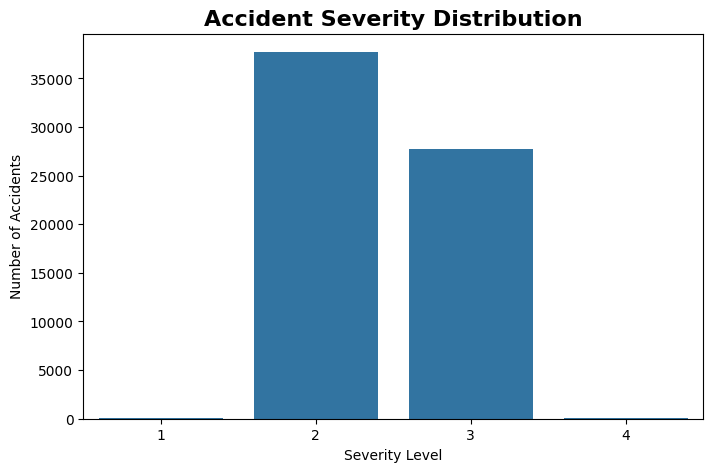

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x="Severity", data=df)
plt.title("Accident Severity Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")
plt.show()

### Insight:
Most accidents are concentrated in lower to medium severity levels. This shows that although many accidents occur frequently, only a smaller portion lead to extremely severe outcomes.

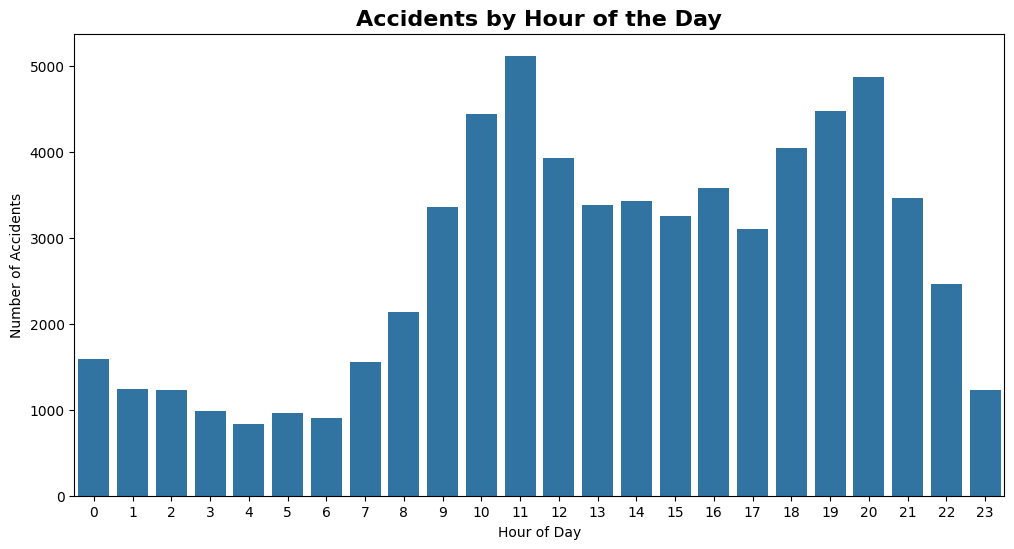

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(x="Hour", data=df)
plt.title("Accidents by Hour of the Day", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.show()

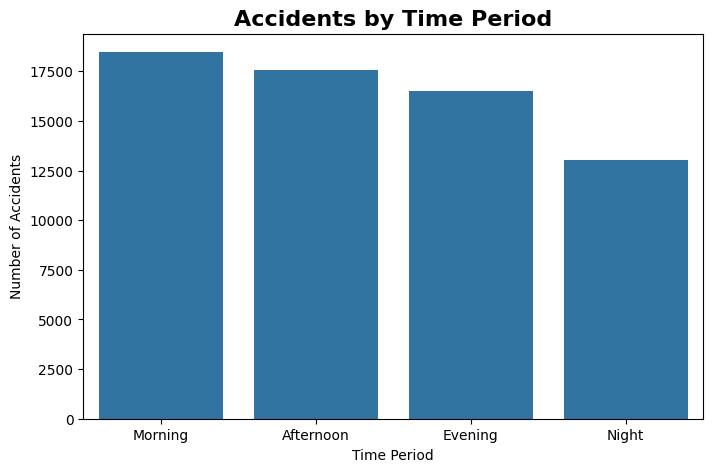

In [16]:
def time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["Time_Period"] = df["Hour"].apply(time_period)

plt.figure(figsize=(8,5))
sns.countplot(x="Time_Period", data=df, order=["Morning", "Afternoon", "Evening", "Night"])
plt.title("Accidents by Time Period", fontsize=16, fontweight="bold")
plt.xlabel("Time Period")
plt.ylabel("Number of Accidents")
plt.show()

### Insight:
Accidents are often higher during morning and evening periods because these hours match office commute and traffic congestion timings.

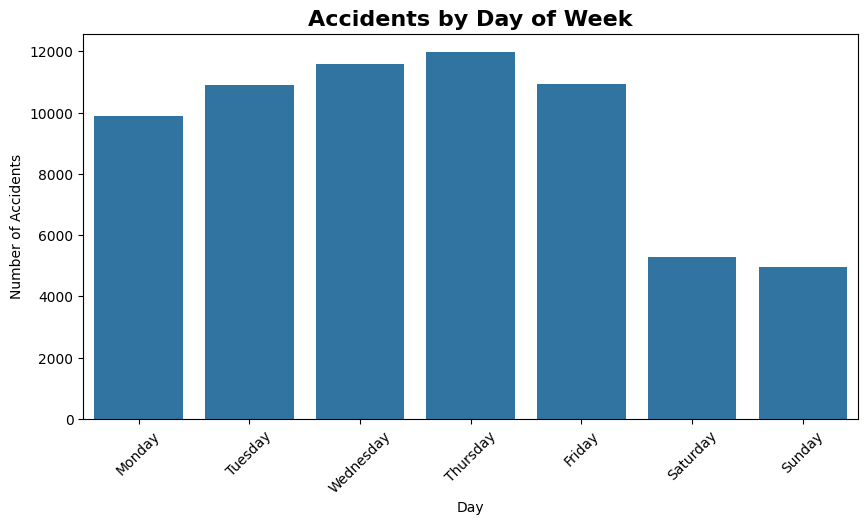

In [17]:
plt.figure(figsize=(10,5))
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.countplot(x="Day_Name", data=df, order=order)
plt.title("Accidents by Day of Week", fontsize=16, fontweight="bold")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

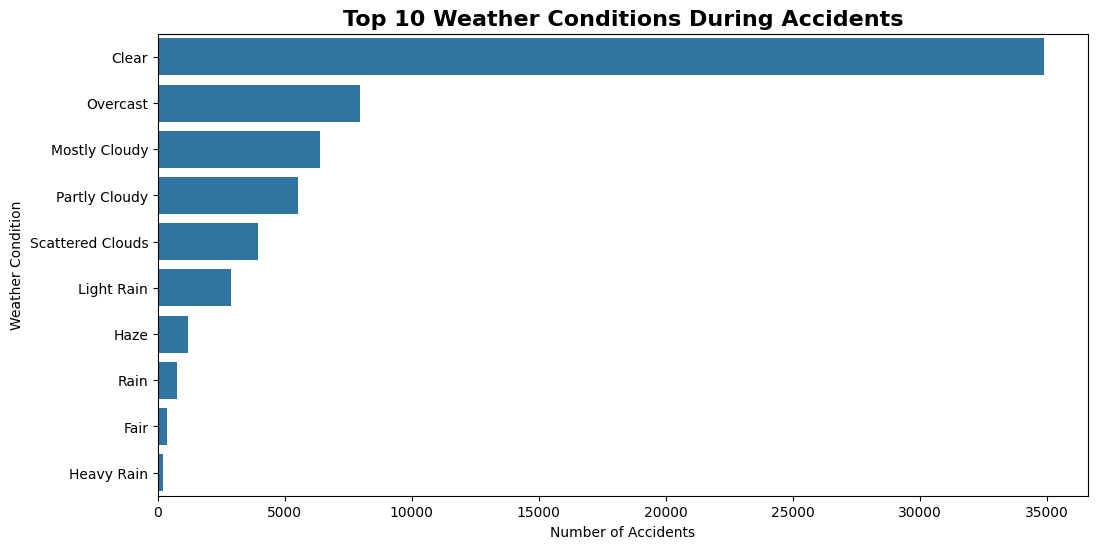

In [19]:
top_weather = df["Weather_Condition"].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_weather.values, y=top_weather.index)
plt.title("Top 10 Weather Conditions During Accidents", fontsize=16, fontweight="bold")
plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")
plt.show()

### Insight:
Most accidents occur under common weather conditions such as fair or cloudy weather. This may be because these conditions occur more frequently overall, not necessarily because they are more dangerous.

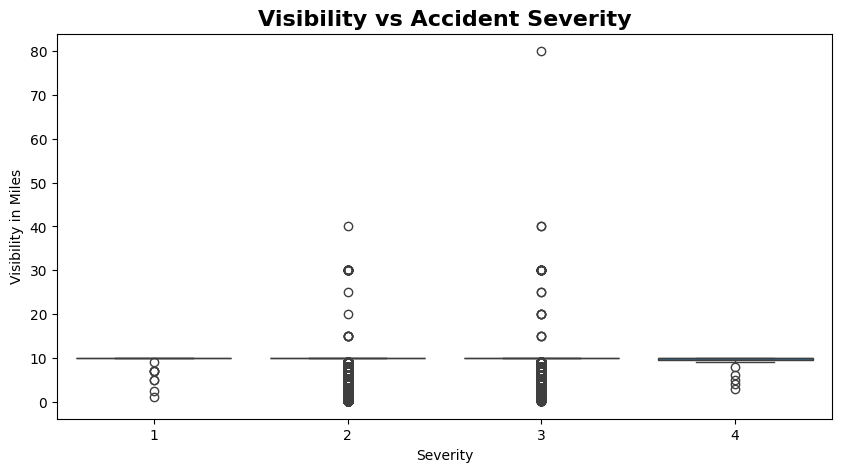

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Severity", y="Visibility(mi)", data=df)
plt.title("Visibility vs Accident Severity", fontsize=16, fontweight="bold")
plt.xlabel("Severity")
plt.ylabel("Visibility in Miles")
plt.show()

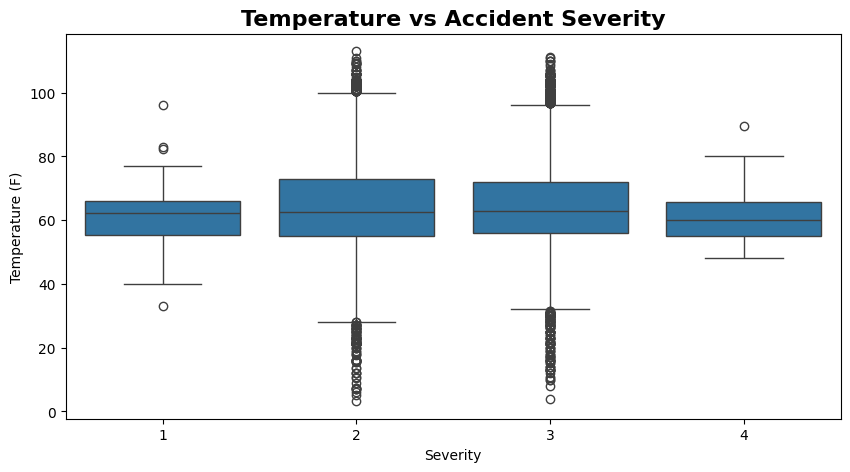

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Severity", y="Temperature(F)", data=df)
plt.title("Temperature vs Accident Severity", fontsize=16, fontweight="bold")
plt.xlabel("Severity")
plt.ylabel("Temperature (F)")
plt.show()

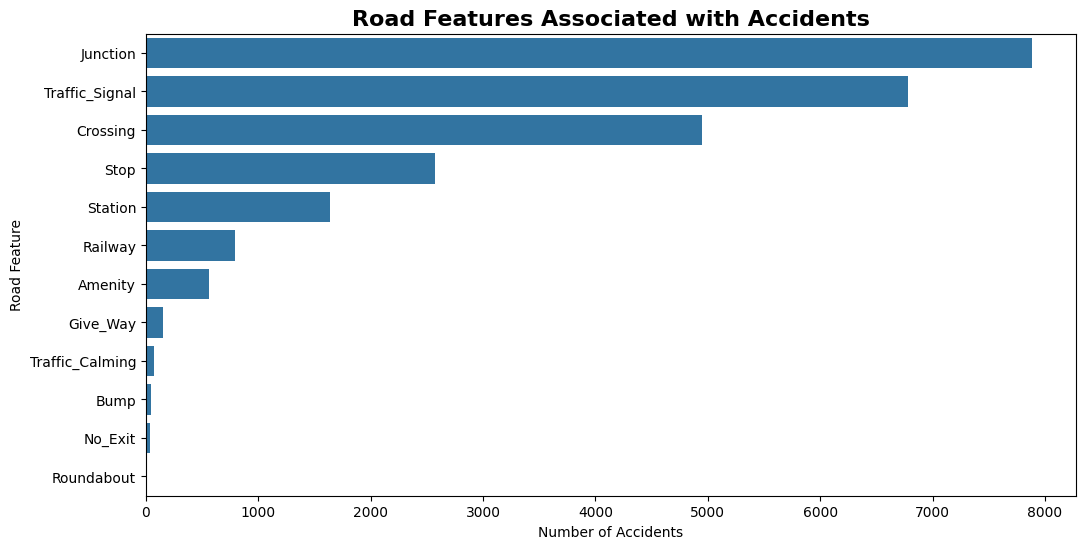

In [22]:
road_features = [
    "Amenity", "Bump", "Crossing", "Give_Way",
    "Junction", "No_Exit", "Railway", "Roundabout",
    "Station", "Stop", "Traffic_Calming",
    "Traffic_Signal"
]

road_counts = df[road_features].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=road_counts.values, y=road_counts.index)
plt.title("Road Features Associated with Accidents", fontsize=16, fontweight="bold")
plt.xlabel("Number of Accidents")
plt.ylabel("Road Feature")
plt.show()

### Insight:
Traffic signals, junctions, and crossings are important contributing locations because vehicles, pedestrians, and road directions interact at these points.

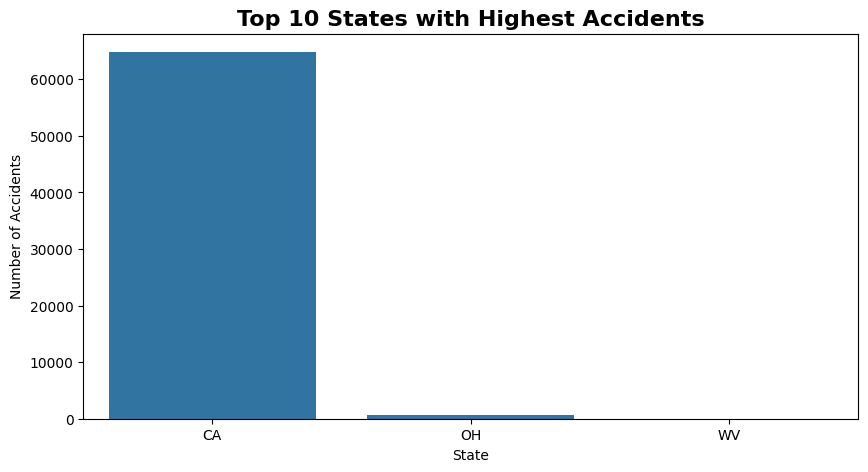

In [23]:
top_states = df["State"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_states.index, y=top_states.values)
plt.title("Top 10 States with Highest Accidents", fontsize=16, fontweight="bold")
plt.xlabel("State")
plt.ylabel("Number of Accidents")
plt.show()

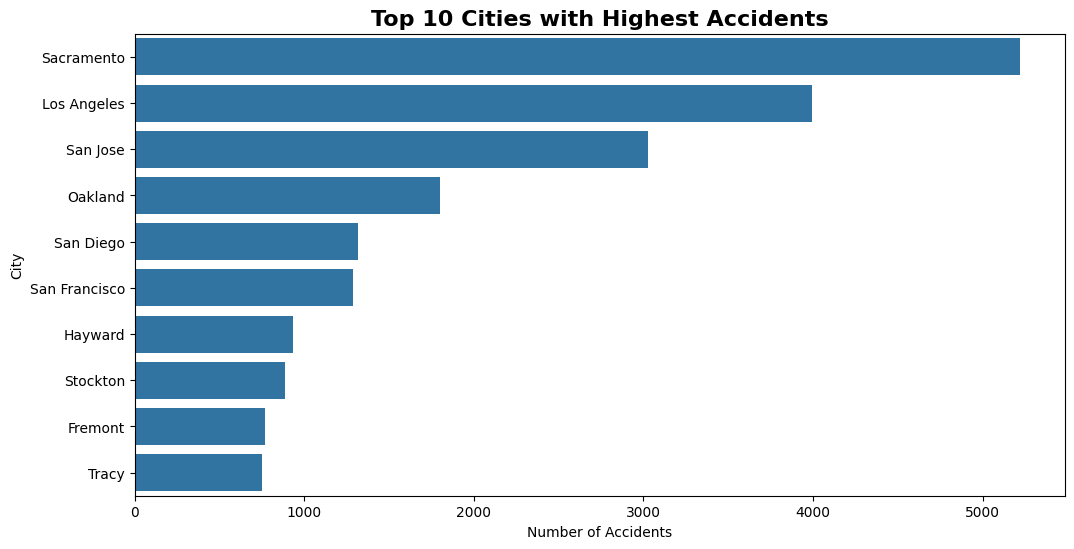

In [24]:
top_cities = df["City"].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top 10 Cities with Highest Accidents", fontsize=16, fontweight="bold")
plt.xlabel("Number of Accidents")
plt.ylabel("City")
plt.show()

In [25]:
map_df = df[["Start_Lat", "Start_Lng"]].dropna().sample(5000, random_state=42)

accident_map = folium.Map(
    location=[map_df["Start_Lat"].mean(), map_df["Start_Lng"].mean()],
    zoom_start=5
)

heat_data = map_df[["Start_Lat", "Start_Lng"]].values.tolist()

HeatMap(heat_data, radius=10).add_to(accident_map)

accident_map

In [26]:
accident_map.save("accident_hotspots_map.html")

### Insight:
The heatmap shows accident hotspots based on geographical concentration. Darker and more intense regions indicate areas where accidents occur more frequently.

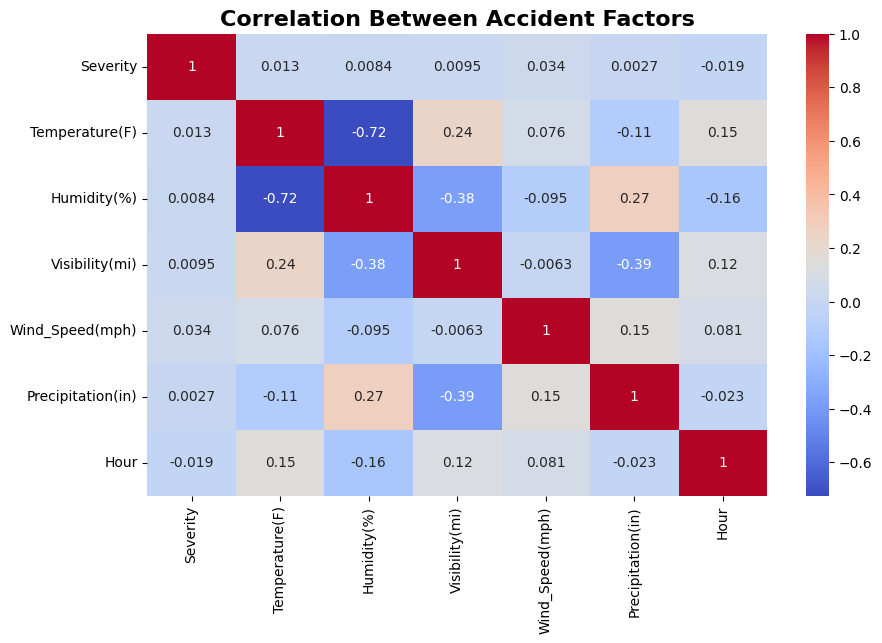

In [28]:
numeric_cols = [
    "Severity", "Temperature(F)", "Humidity(%)",
    "Visibility(mi)", "Wind_Speed(mph)",
    "Precipitation(in)", "Hour"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Accident Factors", fontsize=16, fontweight="bold")
plt.show()

## Final Conclusion

This project analyzed US traffic accident data to identify important patterns related to time, weather, road conditions, and location. The analysis shows that accident frequency is strongly connected with time of day, especially during high-traffic commute hours. Weather conditions such as cloudy, rainy, or low-visibility situations also play an important role in accident occurrence.

The road condition analysis shows that accident-prone areas are often linked with traffic signals, junctions, crossings, and stop points. These locations involve frequent vehicle movement, pedestrian activity, and traffic direction changes, which increase accident risk.

The hotspot map helped identify geographical areas where accidents are highly concentrated. This type of visualization can support traffic departments, city planners, and road safety authorities in identifying risky locations and improving road safety measures.